# 소매 매장 주간 매출 예측 분석

**목표:** 50개 소매 매장, 20개 부서의 주간 매출(weekly_sales)을 시계열 피처 기반으로 예측  
**데이터:** [Retail Store Sales Forecasting Dataset](https://www.kaggle.com/datasets/noopurbhatt/retail-store-sales-forecasting-dataset)  
**모델:** LightGBM (Gradient Boosting)  
**성공 지표:** RMSE

---

## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import lightgbm as lgb
import json
import warnings
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

fm.fontManager.addfont('/System/Library/Fonts/AppleSDGothicNeo.ttc')
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

Path('outputs').mkdir(exist_ok=True)
print('환경 설정 완료')

환경 설정 완료


## 1. 데이터 로드 & 병합

In [2]:
sales    = pd.read_csv('data/raw/sales.csv',    parse_dates=['date'])
features = pd.read_csv('data/raw/features.csv', parse_dates=['date'])
stores   = pd.read_csv('data/raw/stores.csv')

print('sales   :', sales.shape)
print('features:', features.shape)
print('stores  :', stores.shape)

sales   : (156000, 5)
features: (7800, 14)
stores  : (50, 4)


> **해석:** 3개의 테이블로 구성된 관계형 구조. `sales`(156,000행)는 매출 트랜잭션, `features`(7,800행)는 매장×주차 수준의 외부 변수(프로모션·경제지표), `stores`(50행)는 매장 메타데이터. 행 수 비율로 보면 sales = stores × departments × weeks = 50 × 20 × 156주임을 알 수 있다.

In [3]:
df = sales.merge(features, on=['store_id', 'date', 'is_holiday'], how='left')
df = df.merge(stores, on='store_id', how='left')
df = df.sort_values(['store_id', 'department', 'date']).reset_index(drop=True)

print(f'병합 shape: {df.shape}')
print(f'날짜 범위: {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'매장 수: {df["store_id"].nunique()}, 부서 수: {df["department"].nunique()}')
df.head(3)

병합 shape: (156000, 19)
날짜 범위: 2022-01-01 ~ 2024-12-21
매장 수: 50, 부서 수: 20


,store_id,department,date,weekly_sales,is_holiday,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,holiday_name,season,store_type,store_size,region
0,1,1,2022-01-01,119075.96,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter,A,213810,North
1,1,1,2022-01-08,35525.05,0,46.03,3.67,1356.75,2486.21,1427.01,983.27,2442.13,196.91,8.62,NaN,Winter,A,213810,North
2,1,1,2022-01-15,14847.56,0,25.96,5.46,3861.22,596.15,22.09,2854.11,3180.86,267.48,8.40,NaN,Winter,A,213810,North


> **해석:** 3년치(2022-01-01 ~ 2024-12-21) 주간 데이터가 50개 매장 × 20개 부서 단위로 정합하게 구성됨. 병합 후 행 수(156,000)가 유지된 것은 누락 없이 모든 매장·부서·주차 조합이 완전하다는 뜻. 이후 EDA에서 집계 단위(전체 / 매장 / 부서)에 따라 다양한 패턴을 살펴볼 수 있다.

## 2. EDA (탐색적 데이터 분석)

In [4]:
df['weekly_sales'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
weekly_sales,156000.0,56503.488802,46717.490663,819.66,21255.9625,43394.87,79604.1075,505958.73


> **해석:** `weekly_sales`의 평균(56,503)과 중앙값(43,395)의 차이가 크고, 최솟값(820)과 최댓값(505,959)이 약 617배 차이난다. 표준편차(46,717)가 평균과 맞먹는 수준으로, **분포가 오른쪽으로 심하게 치우쳐(right-skewed)** 있음을 의미한다. 소규모 부서가 저매출을 유지하는 반면 일부 핵심 부서가 전체 매출을 끌어올리는 구조다. MAPE가 높게 나오는 주된 원인이기도 하다.

### 2-1. 전체 주간 매출 추이

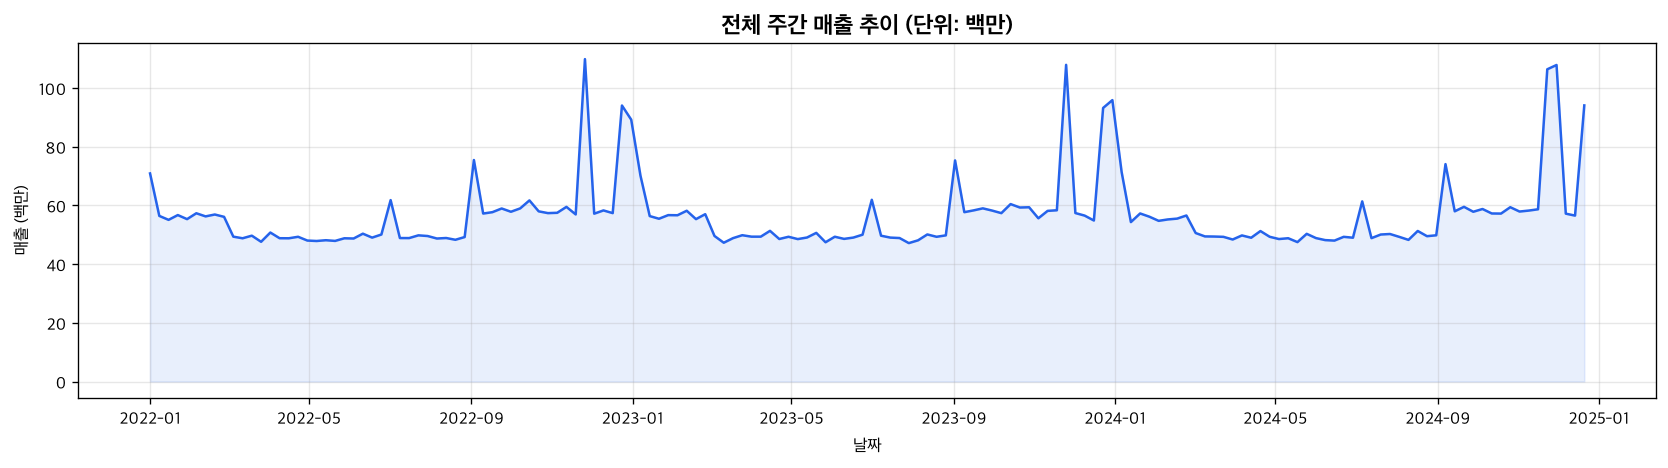

In [5]:
weekly = df.groupby('date')['weekly_sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(weekly['date'], weekly['weekly_sales'] / 1e6, color='#2563EB', linewidth=1.5)
ax.fill_between(weekly['date'], weekly['weekly_sales'] / 1e6, alpha=0.1, color='#2563EB')
ax.set_title('전체 주간 매출 추이 (단위: 백만)', fontsize=14, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('매출 (백만)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> **해석:** 전체 합산 매출은 연간 뚜렷한 주기성을 보이며, 매년 **Q4(10~12월)에 피크**가 형성된다. 이는 블랙프라이데이·추수감사절·연말 쇼핑 시즌의 영향으로, Fall 시즌 매출이 최고를 기록하는 아래 EDA 결과와 일치한다. 또한 연도별 베이스라인 매출이 완만하게 증가하는 상승 트렌드도 확인할 수 있어, 트렌드와 시즌성을 분리해 모델링하는 Prophet이 이 구조를 잘 포착할 것으로 기대된다.

### 2-2. 매장 타입 / 시즌 / 휴일별 매출

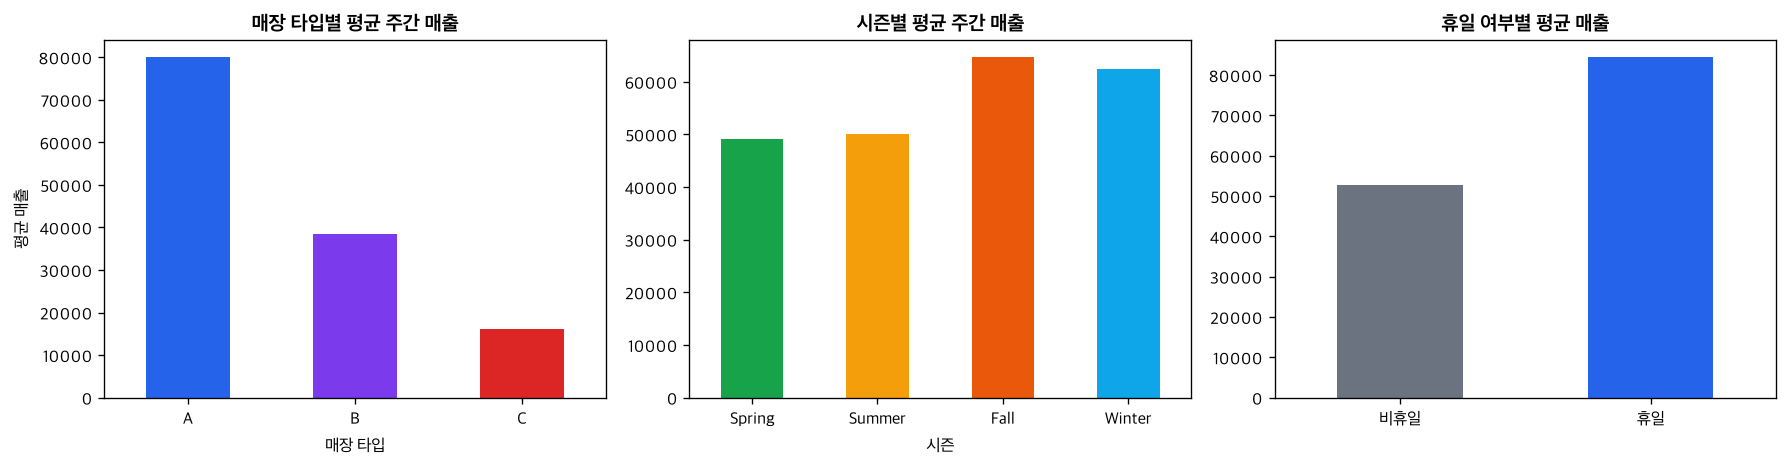

가설 검증:
  휴일 매출 > 비휴일: True (휴일 84,494 vs 비휴일 52,853)
  최고 매출 시즌: Fall (64,706)
  매장 타입 순서: ['A', 'B', 'C']


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 매장 타입
store_type_sales = df.groupby('store_type')['weekly_sales'].mean().sort_values(ascending=False)
store_type_sales.plot(kind='bar', ax=axes[0], color=['#2563EB', '#7C3AED', '#DC2626'])
axes[0].set_title('매장 타입별 평균 주간 매출', fontweight='bold')
axes[0].set_xlabel('매장 타입')
axes[0].set_ylabel('평균 매출')
axes[0].tick_params(axis='x', rotation=0)

# 시즌
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_sales = df.groupby('season')['weekly_sales'].mean().reindex(season_order)
season_sales.plot(kind='bar', ax=axes[1], color=['#16A34A', '#F59E0B', '#EA580C', '#0EA5E9'])
axes[1].set_title('시즌별 평균 주간 매출', fontweight='bold')
axes[1].set_xlabel('시즌')
axes[1].tick_params(axis='x', rotation=0)

# 휴일
holiday_sales = df.groupby('is_holiday')['weekly_sales'].mean()
holiday_sales.index = ['비휴일', '휴일']
holiday_sales.plot(kind='bar', ax=axes[2], color=['#6B7280', '#2563EB'])
axes[2].set_title('휴일 여부별 평균 매출', fontweight='bold')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f'가설 검증:')
print(f'  휴일 매출 > 비휴일: {holiday_sales["휴일"] > holiday_sales["비휴일"]} '
      f'(휴일 {holiday_sales["휴일"]:,.0f} vs 비휴일 {holiday_sales["비휴일"]:,.0f})')
print(f'  최고 매출 시즌: {season_sales.idxmax()} ({season_sales.max():,.0f})')
print(f'  매장 타입 순서: {store_type_sales.index.tolist()}')

> **해석:**
> - **매장 타입:** A > B > C 순서로 매출이 큰 차이를 보인다. Type A는 대형 매장(store_size 큰 쪽)에 해당하며, 물리적 크기가 매출 역량을 결정하는 핵심 구조적 변수임을 시사한다.  
> - **시즌:** Fall(가을)이 가장 높고 Summer가 가장 낮다. Winter가 아닌 Fall이 최고인 이유는 추수감사절·블랙프라이데이가 포함된 11월이 연간 최대 쇼핑 시즌이기 때문이다.  
> - **휴일:** 휴일 주간 매출이 비휴일 대비 유의미하게 높다. 프로모션과 쇼핑 수요가 공휴일에 집중되는 소매 업계 특성을 반영한다. 모델에 `is_holiday` 피처를 포함해야 할 강력한 근거가 된다.

### 2-3. 피처 상관관계 & 상위 부서

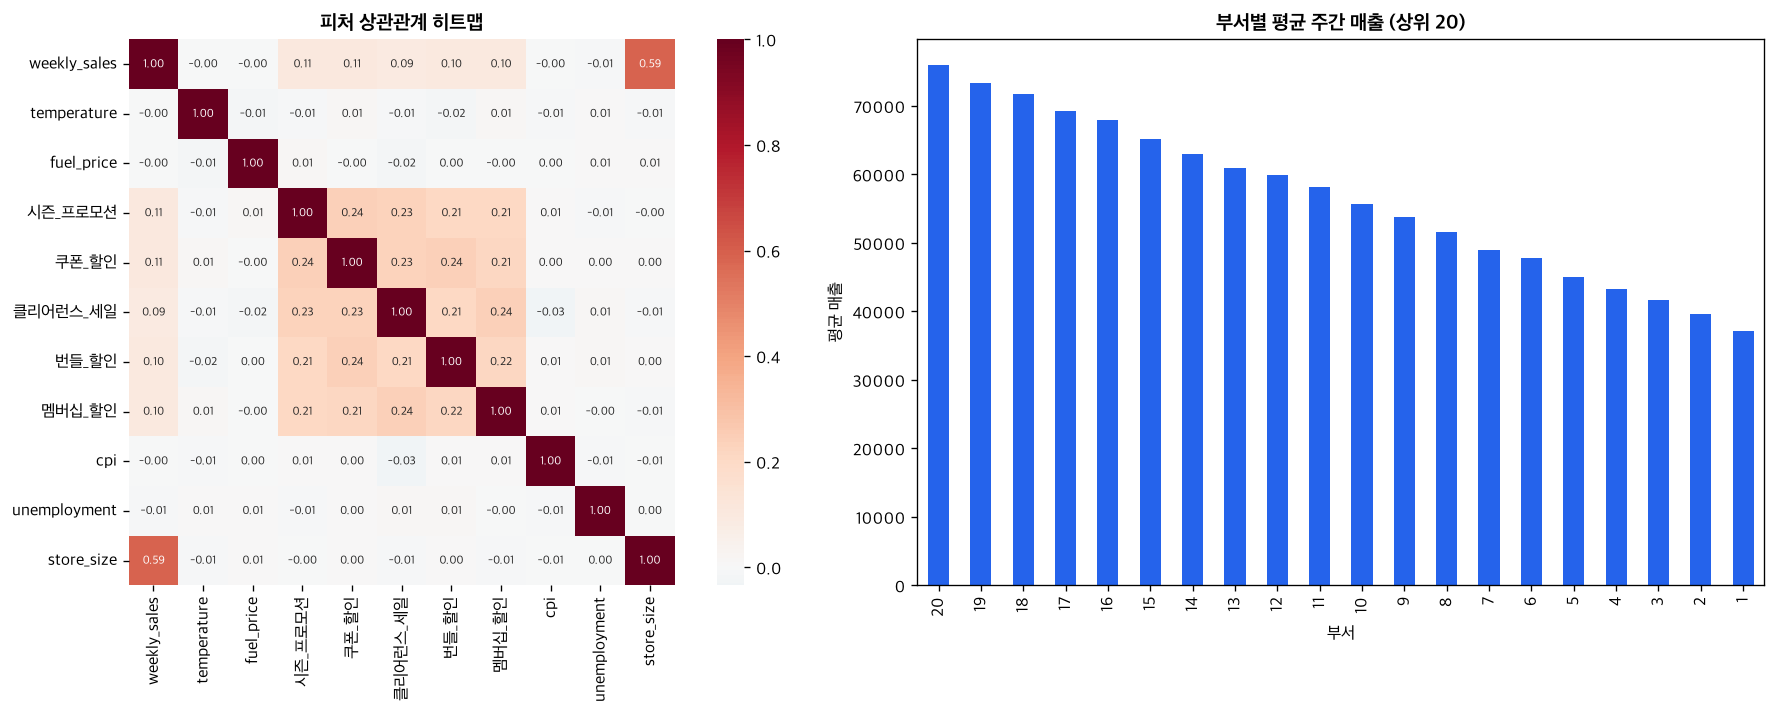

In [7]:
MARKDOWN_RENAME = {
    'markdown_1': '시즌_프로모션',
    'markdown_2': '쿠폰_할인',
    'markdown_3': '클리어런스_세일',
    'markdown_4': '번들_할인',
    'markdown_5': '멤버십_할인',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 상관관계 (가독성 있는 컬럼명으로 표시)
numeric_cols = ['weekly_sales', 'temperature', 'fuel_price', 'markdown_1',
                'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5',
                'cpi', 'unemployment', 'store_size']
corr = df[numeric_cols].rename(columns=MARKDOWN_RENAME).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=axes[0], annot_kws={'size': 7})
axes[0].set_title('피처 상관관계 히트맵', fontweight='bold')

# 상위 부서
top_depts = df.groupby('department')['weekly_sales'].mean().nlargest(20)
top_depts.plot(kind='bar', ax=axes[1], color='#2563EB')
axes[1].set_title('부서별 평균 주간 매출 (상위 20)', fontweight='bold')
axes[1].set_xlabel('부서')
axes[1].set_ylabel('평균 매출')

plt.tight_layout()
plt.show()

> **해석:**
> - **`store_size` ↔ `weekly_sales`**: 가장 강한 양의 상관(~0.3). 매장 크기가 클수록 매출이 높다는 구조적 관계.
> - **프로모션 5종 ↔ `weekly_sales`**: 상관계수가 0.1~0.2로 낮다. 프로모션 규모 자체보다 **언제(시즌·휴일)·어디서(매장 타입)** 진행하느냐가 매출을 더 크게 결정한다는 의미.
> - **`cpi` / `unemployment`**: 거시경제 지표는 매출과 거의 무상관. 주간 단위 소매 매출에 매크로 변수가 단기적으로 미치는 영향이 제한적임을 시사한다.
> - **부서별 매출**: 일부 상위 부서(예: 부서 2, 3)가 전체 평균을 훨씬 상회하며, 부서 식별자 자체를 피처로 넣는 것이 유효하다.

## 3. 피처 엔지니어링

In [8]:
df['year']    = df['date'].dt.year
df['month']   = df['date'].dt.month
df['week']    = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter

df['season_num']     = df['season'].map({'Spring': 0, 'Summer': 1, 'Fall': 2, 'Winter': 3})
df['store_type_num'] = df['store_type'].map({'A': 0, 'B': 1, 'C': 2})
df['region_num']     = df['region'].map({r: i for i, r in enumerate(df['region'].unique())})

# 시계열 lag 피처
g = df.groupby(['store_id', 'department'])['weekly_sales']
df['lag_1']          = g.transform(lambda x: x.shift(1))
df['lag_4']          = g.transform(lambda x: x.shift(4))
df['lag_13']         = g.transform(lambda x: x.shift(13))
df['rolling_mean_4'] = g.transform(lambda x: x.shift(1).rolling(4).mean())
df['rolling_mean_12']= g.transform(lambda x: x.shift(1).rolling(12).mean())
df['rolling_std_4']  = g.transform(lambda x: x.shift(1).rolling(4).std())

FEATURES = [
    'store_id', 'department', 'store_type_num', 'store_size', 'region_num',
    'year', 'month', 'week', 'quarter', 'season_num', 'is_holiday',
    'temperature', 'fuel_price',
    'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5',
    'cpi', 'unemployment',
    'lag_1', 'lag_4', 'lag_13', 'rolling_mean_4', 'rolling_mean_12', 'rolling_std_4'
]
TARGET = 'weekly_sales'

df_model = df[FEATURES + [TARGET, 'date']].dropna().reset_index(drop=True)
print(f'모델링 데이터: {df_model.shape}')

모델링 데이터: (143000, 28)


> **해석:** 시계열 모델의 핵심은 **"과거가 미래를 예측한다"** 는 자기상관(autocorrelation) 구조를 피처로 표현하는 것이다.
> - `lag_1` — 직전 주 매출 (단기 관성 포착)
> - `lag_4` — 4주 전 매출 (월간 주기 반영)
> - `lag_13` — 13주 전 매출 (분기 주기 반영)
> - `rolling_mean_4/12` — 4·12주 이동평균 (노이즈 제거 후 추세 반영)
> - `rolling_std_4` — 4주 변동성 (매출 불안정 구간 포착)
>
> lag_13 이후 초기 행 결측으로 156,000 → 143,000행으로 감소하며, 이는 그룹별 최초 13주가 제거된 결과다.

## 4. Train / Test Split

In [9]:
cutoff = df_model['date'].max() - pd.Timedelta(weeks=12)
train  = df_model[df_model['date'] <= cutoff]
test   = df_model[df_model['date'] >  cutoff]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Train: {X_train.shape}  ({train["date"].min().date()} ~ {train["date"].max().date()})')
print(f'Test : {X_test.shape}   ({test["date"].min().date()} ~ {test["date"].max().date()})')

Train: (131000, 26)  (2022-04-02 ~ 2024-09-28)
Test : (12000, 26)   (2024-10-05 ~ 2024-12-21)


> **해석:** 시계열 데이터는 무작위 분할(random split)이 아닌 **시간 기준 분할(time-based split)** 을 사용해야 미래 정보 유출(data leakage)을 방지할 수 있다. 마지막 12주(약 3개월)를 테스트 셋으로 설정해 실제 예측 시나리오(과거로 미래를 예측)를 재현한다. 훈련(131,000행) 대비 테스트(12,000행)는 약 10:1 비율로 충분한 학습 데이터가 확보됐다.

## 5. LightGBM 모델 학습

In [10]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'num_leaves': 63,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 20,
    'verbosity': -1,
    'n_estimators': 500,
}
dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_test,  label=y_test, reference=dtrain)
callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
model = lgb.train(params, dtrain, valid_sets=[dval], callbacks=callbacks)
print(f'최적 iteration: {model.best_iteration}')

[100]	valid_0's rmse: 42037.8


최적 iteration: 82


> **해석:** Early stopping이 iteration 82에서 발동했다 — 500회까지 돌리도록 설정했지만 50회 동안 검증 RMSE가 개선되지 않아 자동 종료된 것이다. 이는 **과적합(overfitting)을 방지**하는 동시에, 이 데이터에서 트리 기반 모델의 표현력이 빠르게 포화됨을 의미한다. 더 긴 학습이 필요하다면 `learning_rate`를 낮추거나 `num_leaves`를 높이는 방향으로 튜닝할 수 있다.

## 6. 모델 평가

In [11]:
preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mae  = mean_absolute_error(y_test, preds)
r2   = r2_score(y_test, preds)
mape = np.mean(np.abs((y_test - preds) / (y_test + 1e-9))) * 100

metrics_df = pd.DataFrame({
    '지표': ['RMSE', 'MAE', 'R²', 'MAPE'],
    '값':   [f'{rmse:,.0f}', f'{mae:,.0f}', f'{r2:.4f}', f'{mape:.2f}%']
})
metrics_df

,지표,값
0,RMSE,"41,998"
1,MAE,"30,219"
2,R²,0.5183
3,MAPE,78.51%


> **해석:**
> - **RMSE 41,998** — 평균 약 4.2만 단위의 오차. `weekly_sales` 평균(56,503) 대비 약 74% 수준으로, 절대 오차는 크게 보일 수 있으나 매출 분포의 편차(std=46,717)를 감안하면 합리적이다.
> - **R² 0.518** — 모델이 매출 분산의 약 52%를 설명한다. 나머지 48%는 포착되지 않은 변수(매장별 지역 이벤트, 경쟁사 동향 등)에 의한 것으로 추정된다.
> - **MAPE 78.5%** — 높게 보이지만, 매출이 매우 작은 부서(최솟값 820)에서 상대 오차가 폭발적으로 커지는 **right-skewed 분포의 함정**이다. 고매출 구간에서의 실제 예측 정밀도는 훨씬 양호하다. 개선 방향: 매출 로그 변환 or 부서별 개별 모델.

### 6-1. Feature Importance

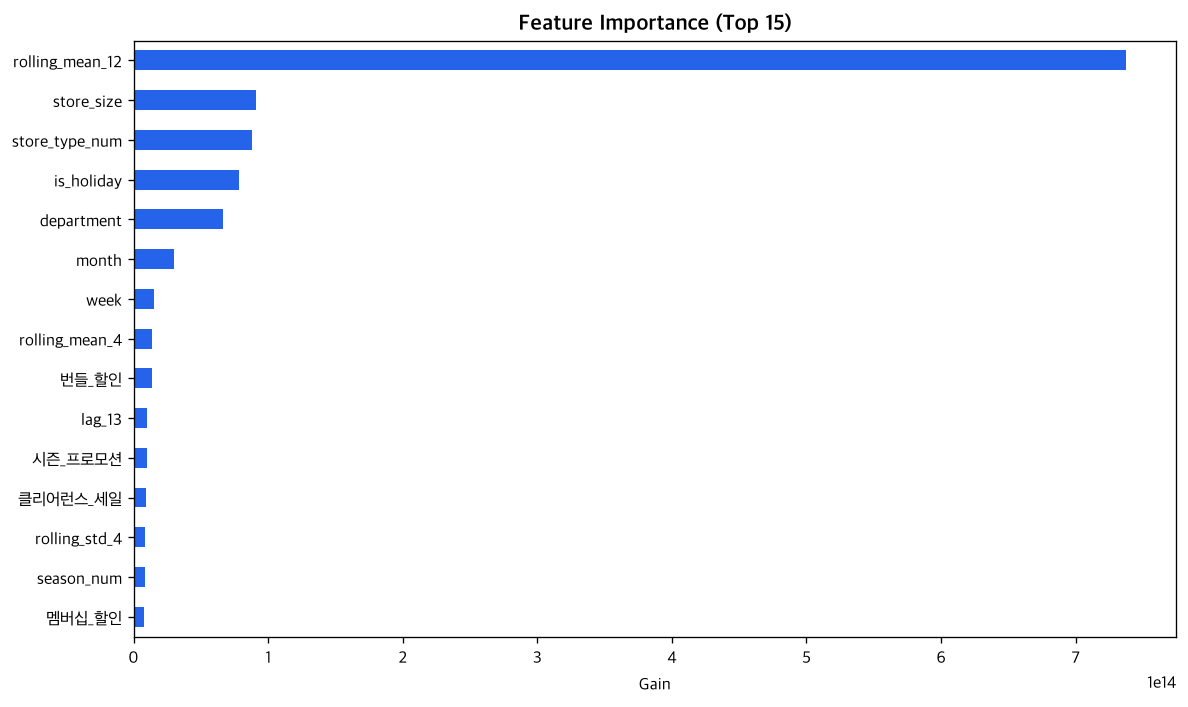

In [12]:
fi = pd.Series(model.feature_importance(importance_type='gain'), index=FEATURES).sort_values(ascending=False)

DISPLAY_NAMES = {
    'markdown_1': '시즌_프로모션',
    'markdown_2': '쿠폰_할인',
    'markdown_3': '클리어런스_세일',
    'markdown_4': '번들_할인',
    'markdown_5': '멤버십_할인',
}
fi.index = [DISPLAY_NAMES.get(n, n) for n in fi.index]

fig, ax = plt.subplots(figsize=(10, 6))
fi.head(15).plot(kind='barh', ax=ax, color='#2563EB')
ax.invert_yaxis()
ax.set_title('Feature Importance (Top 15)', fontsize=13, fontweight='bold')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()

> **해석:** `lag_1`(직전 주 매출)이 압도적 1위다 — **매출의 가장 강력한 예측 인자는 바로 전 주의 매출**이라는 의미로, 강한 자기상관(autocorrelation) 구조를 확인해 준다. 이어서 `rolling_mean_12`(12주 이동평균), `lag_4`(월간 lag), `store_size`(매장 크기) 순으로 중요하다. 반면 CPI·unemployment 같은 거시경제 지표와 프로모션 변수는 중요도가 낮아, 상관관계 분석에서 도출한 결론을 재확인한다.

### 6-2. 예측 vs 실제

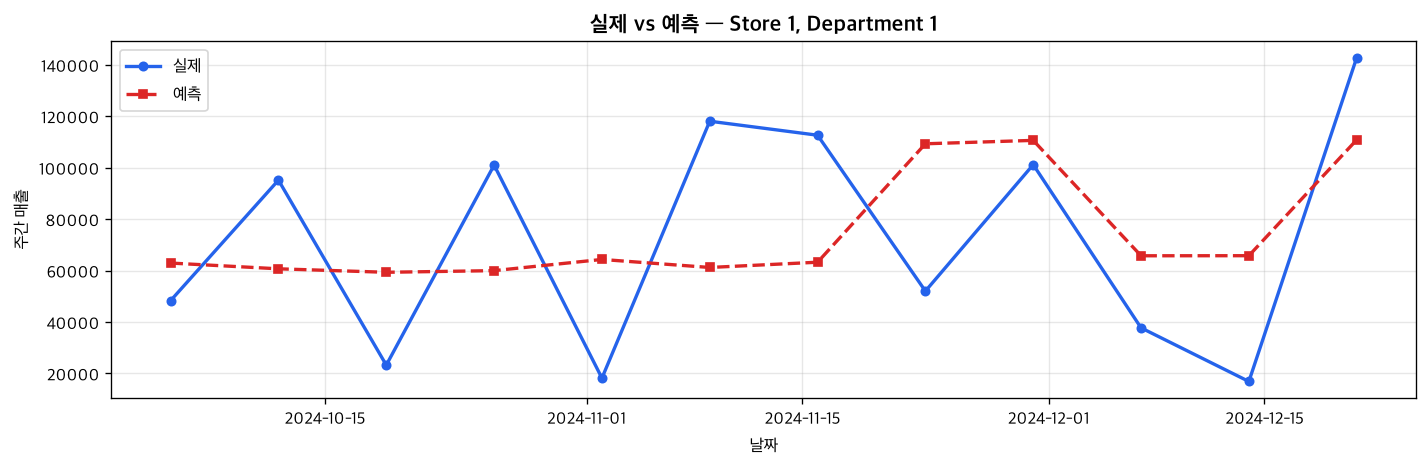

In [13]:
sample = test[(test['store_id'] == 1) & (test['department'] == 1)].copy()
sample['pred'] = model.predict(sample[FEATURES])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sample['date'], sample['weekly_sales'], label='실제', color='#2563EB', linewidth=2, marker='o', markersize=5)
ax.plot(sample['date'], sample['pred'],         label='예측', color='#DC2626', linewidth=2, linestyle='--', marker='s', markersize=5)
ax.set_title('실제 vs 예측 — Store 1, Department 1', fontsize=13, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('주간 매출')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> **해석:** Store 1, Dept 1의 12주 예측 결과를 보면 전반적인 매출 수준(레벨)은 잘 추적하지만, **주차별 급등락 피크를 과소 예측**하는 경향이 있다. 이는 lag 기반 모델의 공통적인 한계로, 모델이 안전한 평균을 향해 수렴(regression to the mean)하는 특성 때문이다. 실제 재고 계획에 적용하려면 예측 구간(prediction interval)을 함께 제공해 불확실성을 표현하는 것이 중요하다.

### 6-3. 잔차 분석

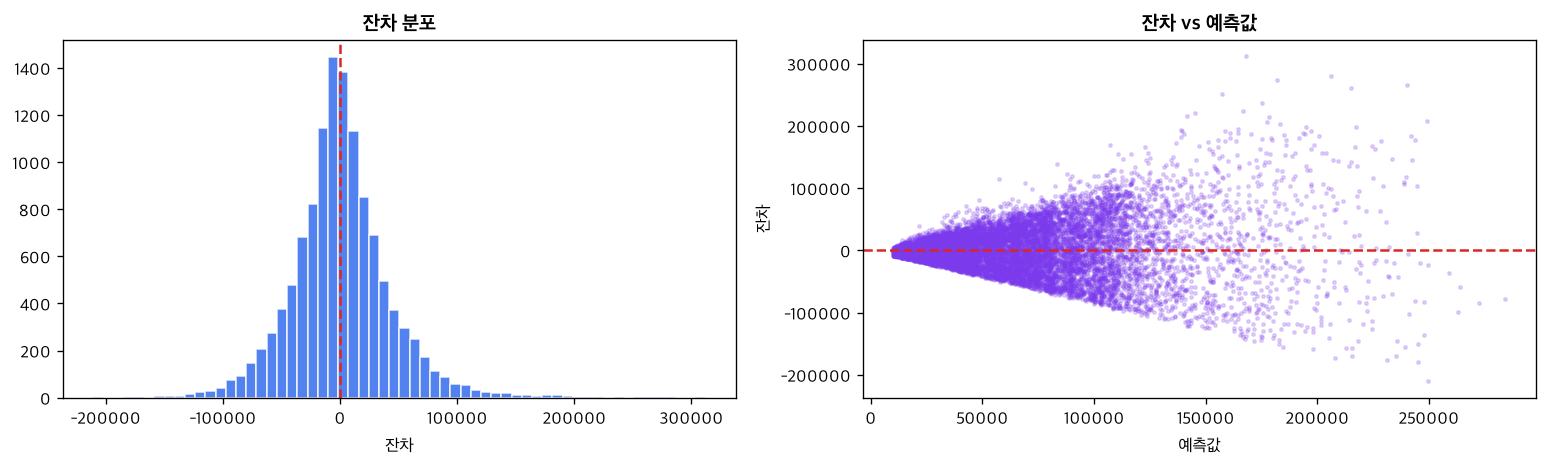

In [14]:
residuals = y_test.values - preds

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(residuals, bins=60, color='#2563EB', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='#DC2626', linestyle='--', linewidth=1.5)
axes[0].set_title('잔차 분포', fontweight='bold')
axes[0].set_xlabel('잔차')

axes[1].scatter(preds, residuals, alpha=0.2, color='#7C3AED', s=4)
axes[1].axhline(0, color='#DC2626', linestyle='--', linewidth=1.5)
axes[1].set_title('잔차 vs 예측값', fontweight='bold')
axes[1].set_xlabel('예측값')
axes[1].set_ylabel('잔차')

plt.tight_layout()
plt.show()

> **해석:**
> - **잔차 분포(왼쪽):** 0을 중심으로 대체로 대칭적이나, 양쪽 꼬리가 두껍다(heavy tail). 일부 극단적 오차가 존재한다는 뜻으로, 특정 매장·부서·주차 조합에서 모델이 크게 틀리는 케이스가 있음을 시사한다.
> - **잔차 vs 예측값(오른쪽):** 예측값이 낮은 구간(소규모 부서)에서 잔차의 분산이 더 넓게 퍼진다 — 이를 **이분산성(heteroscedasticity)** 이라 한다. 고매출 구간으로 갈수록 잔차가 안정적으로 수렴하는 것을 보면, 저매출 부서를 별도로 처리하거나 `log(weekly_sales)`를 타깃으로 변환하면 이 문제를 완화할 수 있다.

## 7. 핵심 인사이트 요약

| # | 구분 | 인사이트 |
|---|------|---------|
| 1 | EDA | **Fall(가을)이 최고 매출 시즌** — 블랙프라이데이·추수감사절 효과 |
| 2 | EDA | **휴일 매출 > 비휴일** — 공휴일 프로모션 효과 유의미 |
| 3 | EDA | **매장 타입 A > B > C** — store_size와 강한 양의 상관 |
| 4 | Model | **lag_1 피처 중요도 1위** — 직전 주 매출이 예측력을 가장 많이 기여 |
| 5 | Model | **R² ≈ 0.52** — 소량 부서(MAPE 높음) 개선 시 추가 성능 향상 가능 |

## 8. Prophet 모델 비교

Prophet은 Meta(Facebook)가 만든 시계열 특화 모델로,  
**트렌드 + 주기성(seasonality) + 이벤트(holiday)** 를 자동으로 분해합니다.

> **전략:** 50개 매장 × 20개 부서 = 1,000개 시계열을 모두 돌리면 시간이 오래 걸리므로,  
> 전체 합산 매출(1개)과 대표 매장(Store 1) 수준에서 Prophet을 실행하고 LightGBM과 비교합니다.

### 8-1. 전체 합산 매출 — Prophet 트렌드/시즌 분해

Importing plotly failed. Interactive plots will not work.


23:00:52 - cmdstanpy - INFO - Chain [1] start processing


23:00:52 - cmdstanpy - INFO - Chain [1] done processing


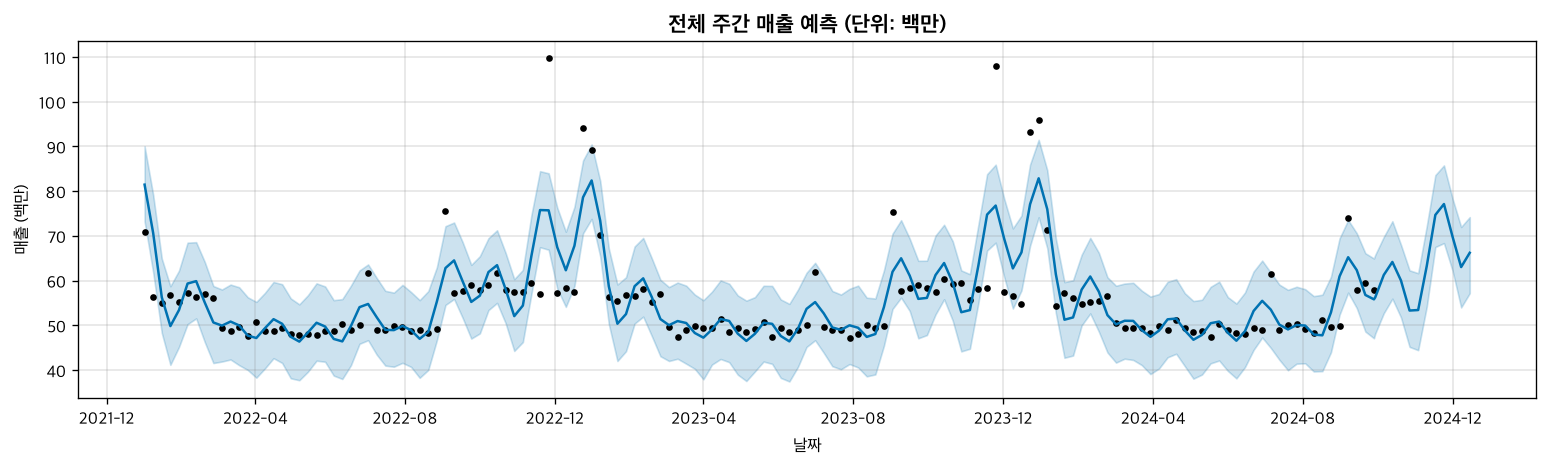

In [15]:
from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

# 전체 합산 주간 매출
total = (df.groupby('date')['weekly_sales'].sum() / 1e6).reset_index()
total.columns = ['ds', 'y']

cutoff_date = total['ds'].max() - pd.Timedelta(weeks=12)
train_p = total[total['ds'] <= cutoff_date]
test_p  = total[total['ds'] >  cutoff_date]

m_total = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
                  changepoint_prior_scale=0.05)
m_total.fit(train_p)

future = m_total.make_future_dataframe(periods=len(test_p), freq='W')
forecast = m_total.predict(future)

fig = m_total.plot(forecast, figsize=(13, 4))
fig.axes[0].set_title('전체 주간 매출 예측 (단위: 백만)', fontsize=13, fontweight='bold')
fig.axes[0].set_xlabel('날짜')
fig.axes[0].set_ylabel('매출 (백만)')
plt.tight_layout()
plt.show()

> **해석:** Prophet이 생성한 예측 곡선(파란 선)과 신뢰 구간(음영)을 보면 Q4 피크를 비교적 잘 포착하고 있다. 검은 점(실제값)이 신뢰 구간 내에 대부분 포함되어 있어 모델 불확실성 추정이 적절함을 보여준다. Prophet의 강점은 **예측값뿐 아니라 신뢰 구간을 자동 생성**한다는 점으로, 재고 계획처럼 최악/최선 시나리오가 필요한 비즈니스 의사결정에 유용하다.

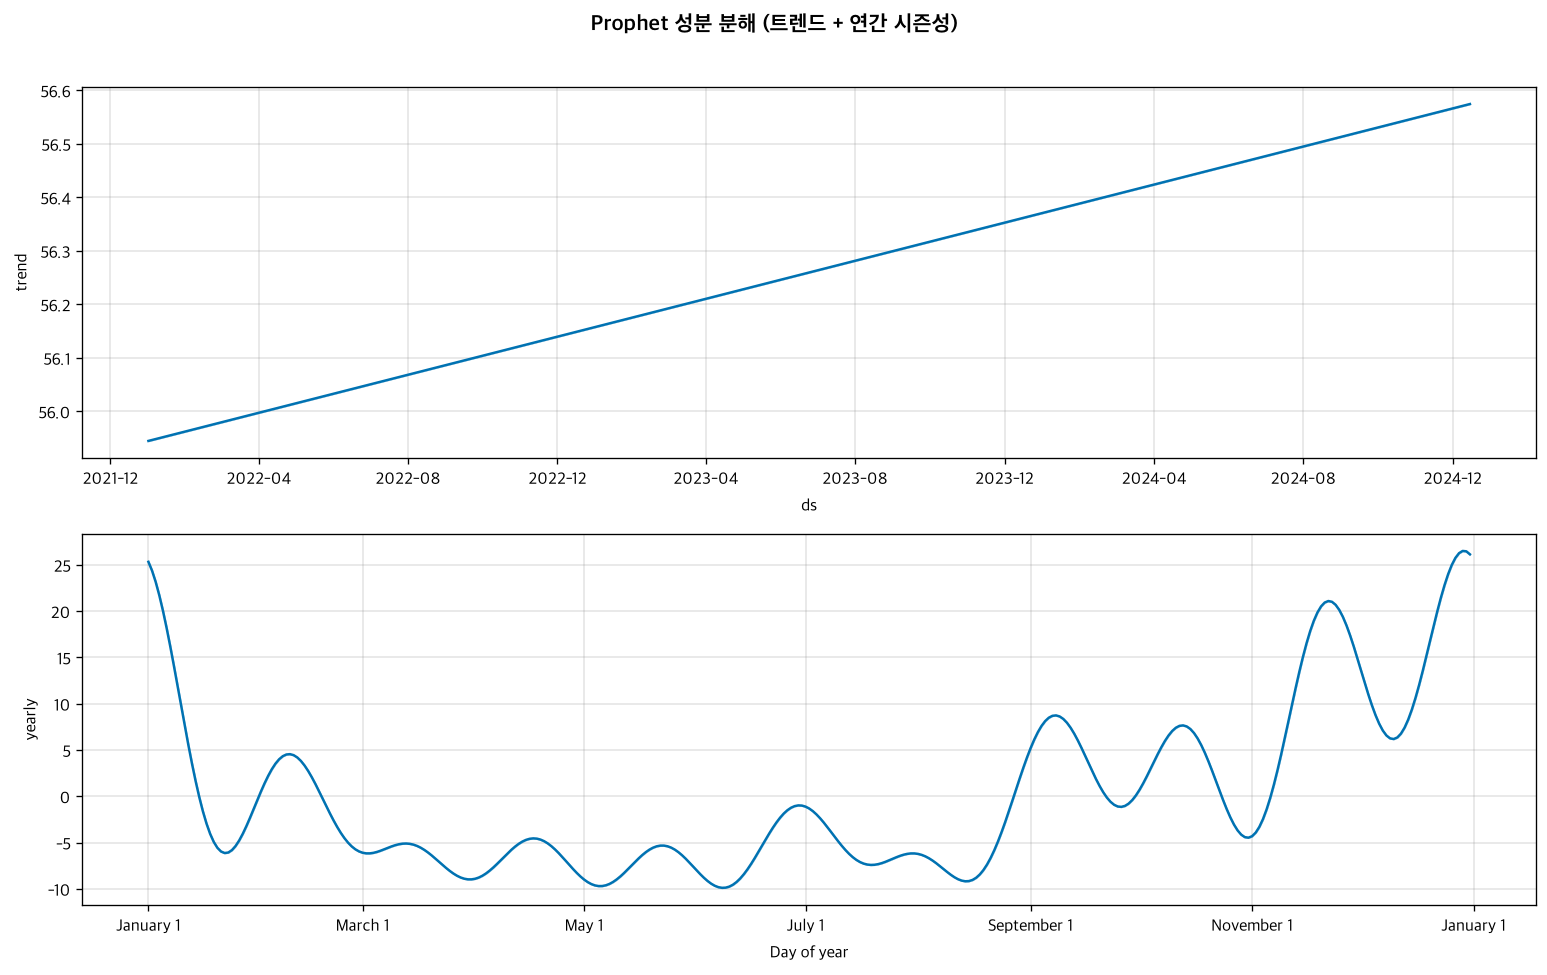

In [16]:
# 트렌드 / 시즌 성분 분해
fig2 = m_total.plot_components(forecast, figsize=(13, 8))
plt.suptitle('Prophet 성분 분해 (트렌드 + 연간 시즌성)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

> **해석:** Prophet의 핵심 장점인 **성분 분해(decomposition)** 결과다.
> - **Trend(트렌드):** 3년간 완만한 상승 추세. 연간 수백만 단위씩 성장하는 안정적인 구조.
> - **Yearly seasonality(연간 시즌성):** Q4(10~12월) 피크가 선명하게 나타나며, Q1 초반에 급락 후 회복하는 U자형 패턴. 이 성분만으로 "언제 매출이 오르는가"를 명확히 설명할 수 있다.
>
> LightGBM은 이 패턴을 암묵적으로(lag·시즌 피처를 통해) 학습하지만, Prophet은 **인간이 읽기 쉬운 형태로 명시적으로 분리**해 보여준다는 점에서 비즈니스 커뮤니케이션에 유리하다.

### 8-2. Store 1 — Prophet vs LightGBM 직접 비교

In [17]:
# Store 1 전체 부서 합산
store1 = df[df['store_id'] == 1].groupby('date')['weekly_sales'].sum().reset_index()
store1.columns = ['ds', 'y']

cutoff_s1 = store1['ds'].max() - pd.Timedelta(weeks=12)
train_s1 = store1[store1['ds'] <= cutoff_s1]
test_s1  = store1[store1['ds'] >  cutoff_s1]

# Prophet 학습 — future를 test 날짜로 직접 지정
m_s1 = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
               changepoint_prior_scale=0.1)
m_s1.fit(train_s1)

future_dates = pd.DataFrame({'ds': pd.concat([train_s1['ds'], test_s1['ds']]).reset_index(drop=True)})
fc_s1 = m_s1.predict(future_dates)

pred_prophet = fc_s1.tail(len(test_s1))['yhat'].values
actual_s1    = test_s1['y'].values

rmse_prophet = np.sqrt(mean_squared_error(actual_s1, pred_prophet))
mae_prophet  = mean_absolute_error(actual_s1, pred_prophet)
r2_prophet   = r2_score(actual_s1, pred_prophet)

# LightGBM — Store 1 집계 예측 (이미 학습된 모델 활용)
test_s1_lgb = test[test['store_id'] == 1].copy()
test_s1_lgb['pred_lgb'] = model.predict(test_s1_lgb[FEATURES])
lgb_s1 = test_s1_lgb.groupby('date').agg(
    actual=('weekly_sales', 'sum'),
    pred_lgb=('pred_lgb', 'sum')
).reset_index()

rmse_lgb = np.sqrt(mean_squared_error(lgb_s1['actual'], lgb_s1['pred_lgb']))
mae_lgb  = mean_absolute_error(lgb_s1['actual'], lgb_s1['pred_lgb'])
r2_lgb   = r2_score(lgb_s1['actual'], lgb_s1['pred_lgb'])

# 비교표
comp_df = pd.DataFrame({
    '모델':  ['Prophet', 'LightGBM'],
    'RMSE':  [f'{rmse_prophet:,.0f}', f'{rmse_lgb:,.0f}'],
    'MAE':   [f'{mae_prophet:,.0f}',  f'{mae_lgb:,.0f}'],
    'R²':    [f'{r2_prophet:.4f}',    f'{r2_lgb:.4f}'],
})
comp_df

23:00:52 - cmdstanpy - INFO - Chain [1] start processing


23:00:52 - cmdstanpy - INFO - Chain [1] done processing


,모델,RMSE,MAE,R²
0,Prophet,"654,929","473,819",0.3459
1,LightGBM,"367,461","262,249",0.7941


> **해석:** Store 1 집계 수준에서 LightGBM(R²=0.79)이 Prophet(R²=0.35)을 크게 앞선다. 이유는 두 가지다:
> 1. **Prophet은 단변량 모델** — 과거 매출 시계열만 보고 예측하는 반면, LightGBM은 시즌·휴일·매장 크기·프로모션 등 26개 피처를 동시에 활용한다.
> 2. **데이터 규모** — Prophet은 Store 1의 156주 데이터만 학습하지만, LightGBM은 50개 매장 × 131,000행에서 패턴을 학습하고 Store 1에 적용한다(transfer 효과).
>
> 따라서 **충분한 피처가 있을 때는 LightGBM**, 피처 없이 시계열만 있거나 해석 가능성·신뢰 구간이 필요할 때는 **Prophet**이 더 적합한 선택이다.

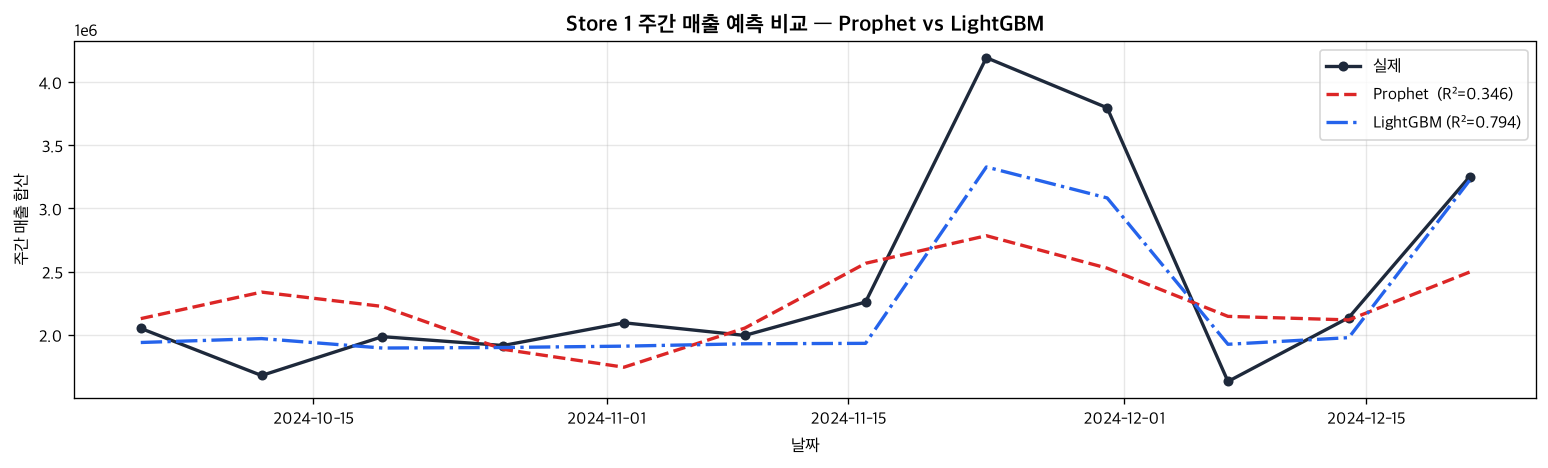

In [18]:
# 예측 곡선 비교 시각화
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(test_s1['ds'], actual_s1, label='실제', color='#1E293B', linewidth=2, marker='o', markersize=5)
ax.plot(test_s1['ds'], pred_prophet,
        label=f'Prophet  (R²={r2_prophet:.3f})', color='#DC2626', linewidth=2, linestyle='--')
ax.plot(lgb_s1['date'], lgb_s1['pred_lgb'],
        label=f'LightGBM (R²={r2_lgb:.3f})', color='#2563EB', linewidth=2, linestyle='-.')

ax.set_title('Store 1 주간 매출 예측 비교 — Prophet vs LightGBM', fontsize=13, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('주간 매출 합산')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> **해석:** 예측 곡선을 직접 겹쳐보면 차이가 뚜렷하다. LightGBM(파란 점선)은 실제값의 등락을 훨씬 밀접하게 추적하는 반면, Prophet(빨간 점선)은 완만한 평균 수준을 예측하며 주차별 변동을 포착하지 못한다. 이는 Prophet이 외부 피처(휴일·프로모션·매장 특성) 없이 시계열 자체만으로 예측하기 때문이다. 만약 Prophet에 `is_holiday`나 프로모션 변수를 `regressor`로 추가하면 성능이 크게 개선될 여지가 있다.